In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/azharcou/tb-and-climate-data-set-in-comilla/tb_project_data.csv")
df.loc[11, 'time'] = '2017-12-01'

In [3]:
df['time'] = pd.to_datetime(df['time'])

# Extract month and year

In [4]:
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

#3-letter month name
df['month_name'] = df['time'].dt.strftime('%b')

# 1.Monthly averages across all years
monthly_avg = df.groupby('month')['total_count'].agg([
    'mean','std','min','max'
]).round(2)
monthly_avg.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


print("=" * 60)
print('MONTHLY AVERAGE TB SUSPECTED CASES')
print('=' * 60)
print(monthly_avg)
print('\n')

#Find peak and low month
peak_month = monthly_avg['mean'].idxmax()
low_month = monthly_avg['mean'].idxmin()
print(f"Peak Month :{peak_month}({ monthly_avg['mean'].max()})")
print(f"Peak Month :{low_month}({ monthly_avg['mean'].min()})")

MONTHLY AVERAGE TB SUSPECTED CASES
       mean     std  min  max
Jan  761.83   74.90  663  854
Feb  717.33   85.90  626  828
Mar  720.83   98.73  611  843
Apr  606.83  191.28  298  759
May  621.83  203.95  308  785
Jun  682.17  195.83  325  829
Jul  706.17   79.49  614  803
Aug  741.83   66.02  622  813
Sep  777.83   74.17  660  863
Oct  804.33   50.22  728  882
Nov  789.33   41.52  738  861
Dec  784.50   41.76  732  851


Peak Month :Oct(804.33)
Peak Month :Apr(606.83)


# Replace 0 rainfall value


In [5]:
df.loc[(df['month_name'] =='Jan') & (df['rainfall_mm'] == 0),'rainfall_mm']=7
df.loc[(df['month_name']=='Feb')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 9
df.loc[(df['month_name']=='Nov')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 10
df.loc[(df['month_name']=='Dec')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 4
df.loc[(df['month_name']=='Mar')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 20

# Seasonal Features (Important for TB seasonality)

In [6]:
 #Define seasons for Bangladesh (South Asian context)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'  # Dec-Feb
    elif month in [3, 4, 5]:
        return 'Summer'  # Mar-May
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'  # Jun-Sep
    else:
        return 'Post-monsoon'  # Oct-Nov

df['season'] = df['month'].apply(get_season)

In [7]:
df.groupby('season')['total_count'].agg(['mean', 'sum', 'std', 'count'])

,mean,sum,std,count
season,,,,
Monsoon,727.000000,17448,114.988846,24
Post-monsoon,796.833333,9562,44.625377,12
Summer,649.833333,11697,169.028800,18
Winter,754.555556,13582,71.816123,18


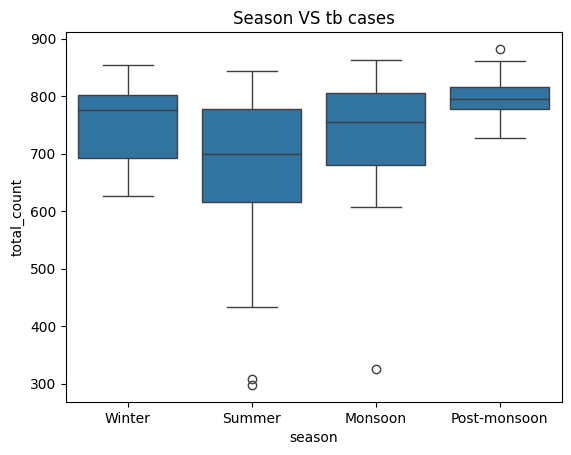

In [8]:
sns.boxplot(x ='season',y ='total_count',data = df)
plt.title('Season VS tb cases')
plt.show()